In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import os
import sys
from pathlib import Path
import glob

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# Experimental conditions

In [33]:
silver_path = Path.cwd().parent / 'data/silver_layer/'

silver_confocal_path = Path.cwd().parent / 'data/silver_layer/confocal_runs'
gold_profile_path = Path.cwd().parent / 'data/gold_layer/profile_pics'

gold_profile_path.mkdir(parents=True, exist_ok=True)

In [34]:
df_confocal = pd.read_pickle(silver_path / 'confocal_results.pkl')
df_experimental = pd.read_pickle(silver_path / 'experimental_results.pkl')

# Selected conditions

In [35]:
missing_threshold = 50

In [36]:
list_runs = df_confocal.loc[df_confocal['t2_missing_percentage']<missing_threshold, 'run_id'].unique()

In [37]:
df_selected = df_experimental.loc[df_experimental['run_id'].isin(list_runs)]

In [38]:
# def profile_plot3(z, i, df, time=1, cm=1/2.56, factor_h=1.5, factor_v=0.5):
#     df3 = z.copy()
#     df3 = df3.loc[~df3['t1'].isna()]
#     df3['time'] = df3['time'] - df3['time'].min()
#     df3.loc[df3['t3'].isna(), 't3'] = 0.96
#     df3.loc[df3['t3']>1.3, 't3'] = df3.loc[df3['t3']>1.3, 't3']*1.51/1.33
#     df3.loc[df3['t2']>8.02, 't3'] = (df3['t2']-8.02)*1.51/1.33
#     df3.loc[df3['t2']>8.02, 't2'] = 8.02
#     df3['t0'] = 0-0.96
#     df3 = df3.loc[df3['time']<time]

#     # Create the plot
#     fig = plt.figure(figsize=(10.9*cm*factor_h, 7.62*cm*factor_v))

#     # Plot lines
#     sns.lineplot(x=df3['time'], y=df3['t0'], color='k')
#     sns.lineplot(x=df3['time'], y=df3['t1']-0.96, color='k')
#     sns.lineplot(x=df3['time'], y=df3['t2'], color='blue', marker='o', markersize=3, alpha=0.5)#'#89CFF0'
#     sns.lineplot(x=df3['time'], y=8.02+0.1, color='k')
#     # sns.lineplot(x=df3['time'], y=8.98, color='k')

#     # Customize axis
#     ax = plt.gca()
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
#     # if i==1|1 or i==4:
#     if i==0:
#         ax.set_xlabel('Time [s]')
#     else:
#         ax.set_xlabel(None)
#     ax.set_ylabel('Profile [mm]')
#     ax.set_ylim(-1.5, 8.5)
#     # ax.set_title(f"{i}: $j_l$: {df['jl'][i]}, $j_g$: {df['jg'][i]}")

#     # Return the figure
#     plt.tight_layout()
#     plt.close(fig)  # Prevent redundant display
#     return fig

In [39]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axes
    "axes.linewidth": 0.6,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",

    # Ticks
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Savefig
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# =========================================================
# Figure dimensions
# =========================================================

CM = 1 / 2.54

FIG_WIDTH_CM = 8.4
FIG_HEIGHT_CM = 2.8

FIG_SIZE = (
    FIG_WIDTH_CM * CM,
    FIG_HEIGHT_CM * CM
)

PLOT_CONFIG = {

    # Geometry
    "glass_thickness": 0.96,
    "channel_height": 8.02,

    # Axis limits
    "ymin": -1.2,
    "ymax": 8.3,

    # Optional crop
    "max_time": None,

    # Corrections
    "t3_threshold": 1.3,
    "t3_scale_num": 1.51,
    "t3_scale_den": 1.33,

    # Plot style
    "wall_color": "black",
    "interface_color": "black",

    "wall_linewidth": 0.7,
    "interface_linewidth": 0.45,

    "interface_alpha": 0.9,
}

In [59]:
# =========================================================
# Utilities
# =========================================================

def cm_to_inch(value_cm):
    return value_cm / 2.54


def load_confocal_run(run_id, base_path=silver_confocal_path):
    """
    Load confocal run CSV.

    Expected columns:
        time, t1, t2, t3
    """

    file_path = base_path / f'confocal_run_{run_id}.csv'

    df = pd.read_csv(file_path)

    return df

In [60]:
def preprocess_profile(df, config=PLOT_CONFIG):
    """
    Apply legacy corrections and preprocessing.
    """

    df = df.copy()

    # -----------------------------------------------------
    # Remove invalid measurements
    # -----------------------------------------------------
    df = df.loc[~df['t1'].isna()].copy()

    # -----------------------------------------------------
    # Normalize time
    # -----------------------------------------------------
    df['time'] = df['time'] - df['time'].min()

    # -----------------------------------------------------
    # Fill missing t3
    # -----------------------------------------------------
    df.loc[df['t3'].isna(), 't3'] = config['glass_thickness']

    # -----------------------------------------------------
    # Legacy t3 correction
    # -----------------------------------------------------
    mask_t3 = df['t3'] > config['t3_threshold']

    df.loc[mask_t3, 't3'] = (
        df.loc[mask_t3, 't3']
        * config['t3_scale_num']
        / config['t3_scale_den']
    )

    # -----------------------------------------------------
    # Overflow correction
    # -----------------------------------------------------
    mask_overflow = df['t2'] > config['channel_height']

    df.loc[mask_overflow, 't3'] = (
        (df.loc[mask_overflow, 't2'] - config['channel_height'])
        * config['t3_scale_num']
        / config['t3_scale_den']
    )

    df.loc[mask_overflow, 't2'] = config['channel_height']

    # -----------------------------------------------------
    # Bottom wall
    # -----------------------------------------------------
    df['t0'] = -config['glass_thickness']


    # -----------------------------------------------------
    # Optional time crop
    # -----------------------------------------------------
    if config['max_time'] is not None:
        df = df.loc[df['time'] < config['max_time']]

    return df

In [61]:
def create_profile_plot(
    df,
    run_id,
    config=PLOT_CONFIG,
    show_xlabel=True,
    show_title=False,
):

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    # -----------------------------------------------------
    # Walls
    # -----------------------------------------------------

    ax.plot(
        df['time'].values,
        df['t0'].values,
        color=config['wall_color'],
        linewidth=config['wall_linewidth']
    )

    ax.plot(
        df['time'].values,
        (df['t1'] - config['glass_thickness']).values,
        color=config['wall_color'],
        linewidth=config['wall_linewidth']
    )

    ax.plot(
        df['time'].values,
        np.full(len(df), config['channel_height'] + 0.1),
        color=config['wall_color'],
        linewidth=config['wall_linewidth']
    )

    # -----------------------------------------------------
    # Interface
    # -----------------------------------------------------

    ax.plot(
        df['time'].values,
        df['t2'].values,
        color=config['interface_color'],
        linewidth=config['interface_linewidth'],
        alpha=config['interface_alpha'],
        rasterized=True
    )

    # -----------------------------------------------------
    # Labels
    # -----------------------------------------------------

    if show_xlabel:
        ax.set_xlabel(r'Time [s]')

    ax.set_ylabel(r'Profile [mm]')

    # -----------------------------------------------------
    # Limits
    # -----------------------------------------------------

    ax.set_ylim(
        config['ymin'],
        config['ymax']
    )

    # -----------------------------------------------------
    # Ticks
    # -----------------------------------------------------

    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )

    # -----------------------------------------------------
    # Style
    # -----------------------------------------------------

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # -----------------------------------------------------
    # Optional title
    # -----------------------------------------------------

    if show_title:
        ax.set_title(f'Run {run_id}')

    return fig

In [62]:
def save_profile_plot(
    fig,
    run_id,
    output_path=gold_profile_path,
    extension='pdf',
):

    save_path = (
        output_path
        / f'profile_run_{run_id}.{extension}'
    )

    fig.savefig(
        save_path,
        format=extension
    )

    plt.close(fig)

    return save_path

In [63]:
# =========================================================
# Batch processing
# =========================================================

def process_profile_runs(
    run_list,
    config=PLOT_CONFIG,
    input_path=silver_confocal_path,
    output_path=gold_profile_path,
):
    """
    Process multiple confocal runs.
    """

    for run_id in run_list:

        print(f'Processing run {run_id}...')

        # ---------------------------------------------
        # Load
        # ---------------------------------------------
        df = load_confocal_run(
            run_id=run_id,
            base_path=input_path
        )

        # ---------------------------------------------
        # Preprocess
        # ---------------------------------------------
        df = preprocess_profile(
            df=df,
            config=config
        )

        # ---------------------------------------------
        # Plot
        # ---------------------------------------------
        fig = create_profile_plot(
            df=df,
            run_id=run_id,
            config=config
        )

        # ---------------------------------------------
        # Save
        # ---------------------------------------------
        save_profile_plot(
            fig=fig,
            run_id=run_id,
            output_path=output_path
        )

        print(f'Finished run {run_id}')


In [69]:
teste = load_confocal_run(
            run_id=13,
            base_path=silver_confocal_path
        )

In [70]:
teste2 = preprocess_profile(teste, PLOT_CONFIG)

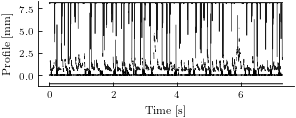

In [71]:
fig = create_profile_plot(
    df=teste2,
    run_id=13,
    config=PLOT_CONFIG
)

In [46]:
# =========================================================
# Example
# =========================================================

# list_runs = [1, 2, 3, 4]

process_profile_runs(
    run_list=list_runs
)

Processing run 13...


KeyError: 't'